In [1]:
import tensorflow as tf

In [2]:
print(tf.__version__)

2.10.1


In [3]:
#import basic libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
dataset = pd.read_csv('Churn_Modelling.csv')

In [24]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [25]:
## divide the dataset into independent and dependent features
X=dataset.iloc[:,3:13]   #iloc selecting columns by index 
y=dataset.iloc[:,13] 

In [26]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [27]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [28]:
## feature engineering 
geography=pd.get_dummies(X['Geography'],drop_first=True).astype(int)
gender=pd.get_dummies(X['Gender'],drop_first=True).astype(int)

In [29]:
##concatenate these above variable in the dataset
X=X.drop(['Geography','Gender'],axis=1)

In [33]:
X=pd.concat([X,geography,gender],axis=1)

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X,y,train_size=0.2,random_state=0)

In [38]:
#feature scaling 
from sklearn.preprocessing import StandardScaler
sc =StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [40]:
X_test

array([[-0.59200304, -0.35825521,  1.01904025, ...,  1.76500038,
        -0.58196914, -1.08456377],
       [-1.35106678,  0.12352963, -1.04309853, ..., -0.56657212,
        -0.58196914, -1.08456377],
       [ 0.52607733,  0.31624357,  1.01904025, ..., -0.56657212,
         1.71830416, -1.08456377],
       ...,
       [-2.40760144, -0.74368308, -1.38678833, ...,  1.76500038,
        -0.58196914, -1.08456377],
       [-1.14591442,  0.2198866 , -0.35571894, ..., -0.56657212,
         1.71830416, -1.08456377],
       [ 1.33642916, -0.26189824, -1.04309853, ...,  1.76500038,
        -0.58196914, -1.08456377]])

In [45]:
## Create a ANN
from tensorflow.keras.models import Sequential  # used for forward and backward progation
from tensorflow.keras.layers import Dense # help to create the hidden layers 
from tensorflow.keras.layers import LeakyReLU, PReLU,ELU,ReLU # activation functions
from tensorflow.keras.layers import Dropout # help to liminate the dead neurons

In [87]:
## lets initial the ann
classifier = Sequential()

In [88]:
#ADDING THE input layer
classifier.add(Dense(units=11,activation='relu')) # activation function will get applied to the next layer on ann


In [89]:
# adding the first hidden layer 
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.2))

In [90]:
#adding the second layer
classifier.add(Dense(units=6,activation='relu'))
classifier.add(Dropout(0.2))

In [91]:
#adding the output layer 
classifier.add(Dense(1,activation='sigmoid'))

In [92]:
classifier.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

In [93]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)


In [94]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
134/134 [==============================] - 5s 22ms/step - loss: 0.5733 - accuracy: 0.7857 - val_loss: 0.5148 - val_accuracy: 0.8064
Epoch 2/1000
134/134 [==============================] - 3s 19ms/step - loss: 0.5054 - accuracy: 0.7946 - val_loss: 0.4757 - val_accuracy: 0.8064
Epoch 3/1000
134/134 [==============================] - 3s 23ms/step - loss: 0.4821 - accuracy: 0.7954 - val_loss: 0.4651 - val_accuracy: 0.8064
Epoch 4/1000
134/134 [==============================] - 3s 20ms/step - loss: 0.4728 - accuracy: 0.7939 - val_loss: 0.4587 - val_accuracy: 0.8064
Epoch 5/1000
134/134 [==============================] - 2s 18ms/step - loss: 0.4719 - accuracy: 0.7961 - val_loss: 0.4554 - val_accuracy: 0.8064
Epoch 6/1000
134/134 [==============================] - 3s 19ms/step - loss: 0.4706 - accuracy: 0.7969 - val_loss: 0.4520 - val_accuracy: 0.8064
Epoch 7/1000
134/134 [==============================] - 2s 18ms/step - loss: 0.4551 - accuracy: 0.7961 - val_loss: 0.4493 - val_ac

In [95]:
model_history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

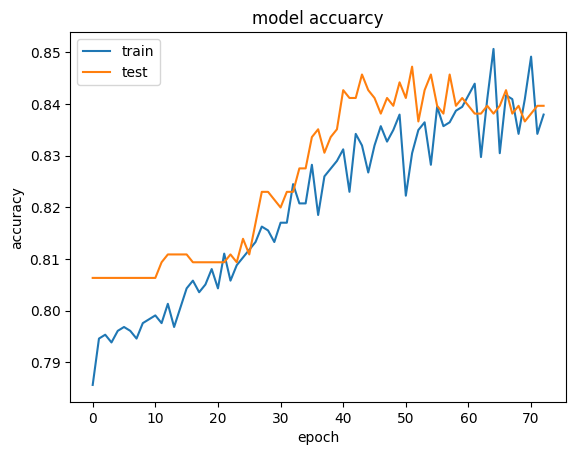

In [96]:
#summary history for the accuracy 
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuarcy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

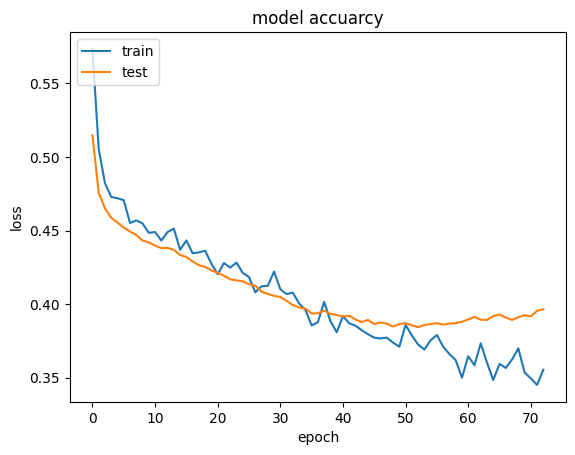

In [97]:
#summary history for the accuracy 
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model accuarcy')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [98]:
# making the prediction and evluating the model 
# predicting rh test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred>=0.5)

250/250 [==============================] - 1s 5ms/step


In [99]:
# make the confusion metrices 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[6160,  204],
       [1097,  539]], dtype=int64)

In [100]:
#calculate the accuarcy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred,y_test)

In [101]:
score

0.837375

In [102]:
##gets the weights 
classifier.get_weights()

[array([[ 0.44561774,  0.06415375, -0.19797008,  0.2675094 , -0.16148224,
          0.43856597,  0.07124291, -0.37024346,  0.36816117,  0.6434325 ,
         -0.1365385 ],
        [ 0.10250314,  0.35380659,  0.01018187,  0.78624374, -0.09715236,
          0.05805821,  0.19541806, -0.8075014 , -0.5812088 , -0.29516104,
         -0.3943711 ],
        [ 0.35961702,  0.05001384,  0.04393451, -0.36053506,  0.40048772,
          0.27975923, -0.28368744, -0.12011202,  0.257984  , -0.72943604,
         -0.15554678],
        [ 0.18183109, -0.17437637,  0.3687586 ,  0.31438458, -0.4309888 ,
          0.08367971, -0.23136066, -0.21615446, -0.06438258,  0.29560474,
         -0.11969046],
        [ 0.05422845, -1.2643474 ,  1.1389718 , -0.42336744,  0.05077373,
          0.5122506 ,  0.37596557, -0.02099073, -0.25389117,  0.07553155,
          0.67952055],
        [ 0.79921424,  0.05318545,  0.16515103, -0.18455729,  0.46038905,
          0.7291902 , -0.23443271, -0.2796244 , -0.04263161, -0.1682671